In [4]:
import numpy as np
import tensorflow as tf
import cv2
import matplotlib.pyplot as plt
import seaborn as sns
import os
from tensorflow.keras.applications import EfficientNetB3
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.models import Model, load_model
from tensorflow.keras.layers import Dense, Dropout, GlobalAveragePooling2D
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import ReduceLROnPlateau, EarlyStopping
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import classification_report, confusion_matrix
from tensorflow.keras.preprocessing import image
from tensorflow.keras.applications.efficientnet import preprocess_input

In [5]:
print("Num GPUs Available:", len(tf.config.list_physical_devices('GPU')))

Num GPUs Available: 0


In [6]:
# Dataset paths
base_dir = "dataset2"
train_dir, val_dir, test_dir = f"{base_dir}/train", f"{base_dir}/val", f"{base_dir}/test"
img_height, img_width, batch_size = 224, 224, 32

In [7]:
# Count number of classes
num_classes = len([folder for folder in os.listdir(train_dir) if os.path.isdir(os.path.join(train_dir, folder))])
classes = sorted(os.listdir(train_dir))
print(f"Number of classes: {num_classes}")

Number of classes: 9


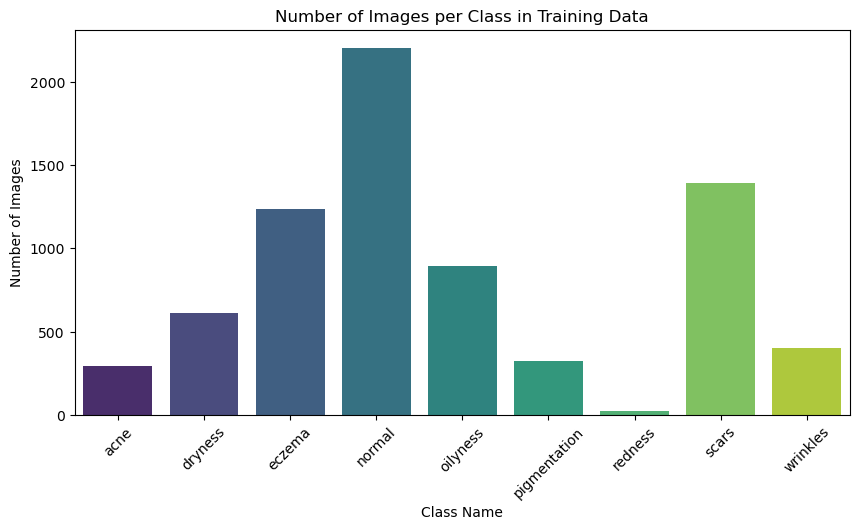

In [8]:
class_counts = {
    class_name: len(os.listdir(os.path.join(train_dir, class_name)))
    for class_name in os.listdir(train_dir)
    if os.path.isdir(os.path.join(train_dir, class_name))
}

# Convert dictionary to sorted lists
classes = list(class_counts.keys())
num_images = list(class_counts.values())

# Plot bar chart
plt.figure(figsize=(10, 5))
sns.barplot(x=classes, y=num_images, hue=classes, palette="viridis", legend=False)

# Labels & Title
plt.xlabel("Class Name")
plt.ylabel("Number of Images")
plt.title("Number of Images per Class in Training Data")
plt.xticks(rotation=45)  # Rotate labels if class names are long

# Show plot
plt.show()

In [9]:
# Data Augmentation for Training Data
train_datagen = ImageDataGenerator(
    preprocessing_function=tf.keras.applications.efficientnet.preprocess_input,
    shear_range=0.2, zoom_range=0.2, rotation_range=30,
    brightness_range=[0.8, 1.2], width_shift_range=0.2, height_shift_range=0.2,
    horizontal_flip=True
)

# No Augmentation for Validation & Testing (Only Preprocessing)
val_test_datagen = ImageDataGenerator(
    preprocessing_function=tf.keras.applications.efficientnet.preprocess_input
)

# Data Generators
train_gen = train_datagen.flow_from_directory(
    train_dir, target_size=(img_height, img_width), batch_size=batch_size, class_mode='categorical'
)

val_gen = val_test_datagen.flow_from_directory(
    val_dir, target_size=(img_height, img_width), batch_size=batch_size, class_mode='categorical'
)

test_gen = val_test_datagen.flow_from_directory(
    test_dir, target_size=(img_height, img_width), batch_size=1, class_mode='categorical', shuffle=False
)


Found 7386 images belonging to 9 classes.
Found 921 images belonging to 9 classes.
Found 928 images belonging to 9 classes.


In [10]:
list(train_gen.class_indices.keys())

['acne',
 'dryness',
 'eczema',
 'normal',
 'oilyness',
 'pigmentation',
 'redness',
 'scars',
 'wrinkles']

In [11]:
# Load Pre-trained Model (EfficientNetB3)
base_model = EfficientNetB3(weights='imagenet', include_top=False, input_shape=(224, 224, 3))

43941136/43941136 ━━━━━━━━━━━━━━━━━━━━ 124s 3us/step


In [12]:
# Fine-tune deeper layers
for layer in base_model.layers[:100]:
    layer.trainable = False
for layer in base_model.layers[100:]:
    layer.trainable = True

In [13]:
# Build Custom Model
x = GlobalAveragePooling2D()(base_model.output)
x = Dense(512, activation="relu")(x)
x = Dropout(0.5)(x)
x = Dense(256, activation="relu")(x)
x = Dropout(0.3)(x)
out = Dense(num_classes, activation="softmax")(x)
model = Model(inputs=base_model.input, outputs=out)

In [14]:
# Compile Model
model.compile(optimizer=Adam(learning_rate=1e-5), loss="categorical_crossentropy", metrics=["accuracy"])

In [15]:
# Compute Class Weights
class_weights = compute_class_weight("balanced", classes=np.unique(train_gen.classes), y=train_gen.classes)
class_weights = dict(enumerate(class_weights))

In [16]:
# Learning Rate Scheduling
lr_schedule = ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3, min_lr=1e-7, verbose=1)

In [17]:
# Early stopping: stop if val_loss hasn’t improved in 5 epochs,
# and roll back to the best weights automatically
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True,
    verbose=1
)

In [18]:
# Supress super class warning
import warnings
warnings.filterwarnings("ignore", category=UserWarning)

In [20]:
with tf.device('/device:GPU:0'):
  # Train Model
  history = model.fit(train_gen, validation_data=val_gen, epochs=5, steps_per_epoch=len(train_gen),
                    validation_steps=len(val_gen), class_weight=class_weights, callbacks=[lr_schedule, early_stop])

Epoch 1/5
231/231 ━━━━━━━━━━━━━━━━━━━━ 1680s 7s/step - accuracy: 0.1561 - loss: 2.2768 - val_accuracy: 0.3822 - val_loss: 1.9727 - learning_rate: 1.0000e-05
Epoch 2/5
231/231 ━━━━━━━━━━━━━━━━━━━━ 1644s 7s/step - accuracy: 0.2715 - loss: 2.1111 - val_accuracy: 0.5092 - val_loss: 1.8126 - learning_rate: 1.0000e-05
Epoch 3/5
231/231 ━━━━━━━━━━━━━━━━━━━━ 1585s 7s/step - accuracy: 0.3888 - loss: 1.8235 - val_accuracy: 0.5722 - val_loss: 1.6023 - learning_rate: 1.0000e-05
Epoch 4/5
231/231 ━━━━━━━━━━━━━━━━━━━━ 1628s 7s/step - accuracy: 0.4909 - loss: 1.6753 - val_accuracy: 0.6189 - val_loss: 1.3955 - learning_rate: 1.0000e-05
Epoch 5/5
231/231 ━━━━━━━━━━━━━━━━━━━━ 1821s 8s/step - accuracy: 0.5464 - loss: 1.5424 - val_accuracy: 0.6450 - val_loss: 1.2126 - learning_rate: 1.0000e-05
Restoring model weights from the end of the best epoch: 5.


In [ ]:
# Save Model
model.save("model-v2.keras")

In [ ]:
# Plot Training History
def plot_training(history):
    plt.figure(figsize=(12, 5))
    plt.subplot(1, 2, 1)
    plt.plot(history.history['accuracy'], label='accuracy')
    plt.plot(history.history['val_accuracy'], label='val_accuracy')
    plt.xlabel('Epochs')
    plt.ylabel('Accuracy')
    plt.legend()
    plt.subplot(1, 2, 2)
    plt.plot(history.history['loss'], label='loss')
    plt.plot(history.history['val_loss'], label='val_loss')
    plt.xlabel('Epochs')
    plt.ylabel('Loss')
    plt.legend()
    plt.show()
plot_training(history)

In [ ]:
# Load Model
loaded_model = load_model("model-v2.keras")

In [ ]:
# Test-Time Augmentation (TTA)
def tta_predict(model, image_gen, tta_rounds=5):
    predictions = []
    for _ in range(tta_rounds):
        preds = model.predict(image_gen, verbose=0)
        predictions.append(preds)
    return np.mean(predictions, axis=0)

In [ ]:
import json

def evaluate_model():
    true_labels = test_gen.classes
    pred_probs = tta_predict(loaded_model, test_gen)
    pred_labels = np.argmax(pred_probs, axis=1)

    # Confusion Matrix
    cm = confusion_matrix(true_labels, pred_labels)
    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=classes, yticklabels=classes)
    plt.xlabel("Predicted")
    plt.ylabel("True")
    plt.title("Confusion Matrix")
    plt.show()

    # Classification Report
    class_report = classification_report(true_labels, pred_labels, target_names=classes, output_dict=True)

    # Format values to 2 decimal places
    for label, metrics in class_report.items():
        if isinstance(metrics, dict):
            for metric, value in metrics.items():
                if isinstance(value, float):  # Check if it's a float
                    metrics[metric] = round(value, 2)
        else:
            class_report[label] = round(metrics, 2)  # For accuracy, macro avg, weighted avg, etc.

    # Print the classification report
    print("Classification Report:")
    print(classification_report(true_labels, pred_labels, target_names=classes))

    # Save the classification report as JSON
    with open("classification_report.json", "w") as f:
        json.dump(class_report, f, indent=4)

    print("Classification report saved as 'classification_report.json'")

# Run evaluation
evaluate_model()


In [ ]:
def predict_skin_condition(image_path, model, top_k=3):
    # Automatically extract class names from the model
    class_indices = model.output_shape[-1]  # Get the number of output classes
    class_names = list(train_gen.class_indices.keys())  # Extract class names

    if len(class_names) != class_indices:
        raise ValueError("Mismatch between model output classes and dataset classes!")

    # Load and preprocess the image
    img = image.load_img(image_path, target_size=(224, 224))
    img_array = image.img_to_array(img)
    img_array = np.expand_dims(img_array, axis=0)
    img_array = tf.keras.applications.efficientnet.preprocess_input(img_array)  # Normalize

    # Make predictions
    pred_probs = model.predict(img_array)[0]  # Get probability vector
    top_indices = np.argsort(pred_probs)[::-1][:top_k]  # Get top-k class indices
    top_classes = [class_names[i] for i in top_indices]
    top_confidences = [pred_probs[i] * 100 for i in top_indices]  # Convert to percentages

    # Display the image with the top prediction
    img_cv2 = cv2.imread(image_path)
    img_cv2 = cv2.cvtColor(img_cv2, cv2.COLOR_BGR2RGB)

    plt.figure(figsize=(6, 6))
    plt.imshow(img_cv2)
    plt.axis("off")
    plt.title(f"Predicted: {top_classes[0]} ({top_confidences[0]:.2f}%)", fontsize=14, fontweight="bold", color="red")
    plt.show()

    # Print top predictions
    print("\nTop Predictions:")
    for i in range(top_k):
        print(f"{top_classes[i]}: {top_confidences[i]:.2f}%")

    # Return results
    return {
        "Predicted": (top_classes[0], top_confidences[0]),
        "Top_3": list(zip(top_classes, top_confidences))
    }

In [ ]:
image_path = "test2.jpg"
prediction_results = predict_skin_condition(image_path, loaded_model)

print("\nFinal Prediction:", prediction_results["Predicted"])
print("Top 3 Predictions:", prediction_results["Top_3"])


In [ ]:

def highlight_infected_areas(image_path, model, img_height=224, img_width=224, threshold=0.5):

    # 🔹 Load image
    img = cv2.imread(image_path)
    img_resized = cv2.resize(img, (img_height, img_width))
    img_array = np.expand_dims(img_resized, axis=0)
    img_array = preprocess_input(img_array)

    # 🔹 Find last convolutional layer dynamically
    last_conv_layer = None
    for layer in reversed(model.layers):
        if 'conv' in layer.name:
            last_conv_layer = layer.name
            break
    if not last_conv_layer:
        raise ValueError("Could not find a convolutional layer in the model.")

    # 🔹 Define Grad-CAM model
    grad_model = tf.keras.models.Model(
        [model.inputs], [model.get_layer(last_conv_layer).output, model.output]
    )

    # 🔹 Get predictions and conv output
    with tf.GradientTape() as tape:
        conv_output, predictions = grad_model(img_array)
        class_idx = tf.argmax(predictions[0])  # Get index of top class
        class_output = predictions[0][class_idx]

        # 🔹 Track gradients for the convolutional layer
        tape.watch(conv_output)

    # 🔹 Compute gradients of class output w.r.t. last conv layer
    grads = tape.gradient(class_output, conv_output)
    pooled_grads = tf.reduce_mean(grads, axis=(0, 1, 2))

    # 🔹 Compute Grad-CAM heatmap
    heatmap = tf.reduce_sum(tf.multiply(pooled_grads, conv_output), axis=-1)[0].numpy()
    heatmap = np.maximum(heatmap, 0)  # ReLU (removes negative values)
    heatmap = cv2.resize(heatmap, (img_resized.shape[1], img_resized.shape[0]))

    # 🔹 Normalize heatmap to [0, 1]
    heatmap = (heatmap - np.min(heatmap)) / (np.max(heatmap) - np.min(heatmap) + 1e-10)

    # 🔹 Create a binary mask based on threshold
    mask = np.uint8(heatmap > threshold) * 255

    # 🔹 Find contours of infected areas
    contours, _ = cv2.findContours(mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

    # 🔹 Create a copy of the image for highlighting
    highlighted_img = img_resized.copy()

    # 🔹 Apply a soft glow effect instead of a sharp outline
    mask_layer = np.zeros_like(highlighted_img)

    for contour in contours:
        # Fill the infected area with red glow
        cv2.drawContours(mask_layer, [contour], -1, (0, 0, 255), thickness=cv2.FILLED)

    # 🔹 Apply Gaussian Blur to create a soft glow effect
    blurred_mask = cv2.GaussianBlur(mask_layer, (25, 25), 10)

    # 🔹 Merge the glow effect with the original image
    highlighted_img = cv2.addWeighted(highlighted_img, 0.7, blurred_mask, 0.3, 0)

    # 🔹 Display the result
    plt.figure(figsize=(6, 6))
    plt.imshow(cv2.cvtColor(highlighted_img, cv2.COLOR_BGR2RGB))
    plt.axis('off')
    plt.show()

    return highlighted_img

In [ ]:
highlighted_image = highlight_infected_areas(image_path, loaded_model)